# OLS Modeling - dataset4 (derived_full + dummies)

- 데이터: `../data/Finance_Final/dataset4_derived_full_with_dummies.csv`
- 타깃: `oil_diff_target` (= 다음날 OilPrice 의 1차 차분)

**진행 순서**

0. 변수 정상성 검정 (ADF + KPSS) → 비정상/판단보류 변수 제외, 완전 중복 변수 제거 (전처리 — 검정 결과로만 결정, 추측 X)
1. OLS 적합
2. VIF 점검
3. 잔차 진단 — 자기상관(ACF/PACF + Ljung-Box + DW), 이분산성(Breusch-Pagan)
4. 결론 (이후 단계)


In [85]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_PATH = Path("../data/Finance_Final/dataset4_derived_full_with_dummies.csv")
TARGET = "oil_diff_target"

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date").sort_index()
print("shape:", df.shape)
print("기간:", df.index.min().date(), "~", df.index.max().date())
print("컬럼:", list(df.columns))
df.head()


shape: (4799, 43)
기간: 2007-02-01 ~ 2026-03-16
컬럼: ['oil_diff_target', 'OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'FedFundsRate', 'oil_diff_lag1', 'oil_diff_lag5', 'oil_volatility_5', 'oil_volatility_20', 'MA_5', 'MA_20', 'MA_ratio', 'MA_5_gt_MA_20', 'oil_momentum_5', 'oil_momentum_20', 'TermSpread_inversion', 'vix_high', 'is_monday', 'is_friday', 'gfc_2008_shock', 'gfc_2008_regime', 'opec_2014_shock', 'opec_2014_regime', 'covid_2020_shock', 'covid_2020_regime', 'war_2022_shock', 'war_2022_regime', 'gfc_2008_window', 'opec_2014_window', 'covid_2020_window', 'war_2022_window', 'cond_vix_gt_30', 'cond_termspread_inv', 'cond_inventory_draw', 'cond_opec_cut']


,oil_diff_target,OilPrice,RealInterestRate,CPI,DollarIndex,VIX,IndustryProduction,CPE,OilInventories,OPECProduction,OilProduction,TreasuryYield,FedFundsRate,oil_diff_lag1,oil_diff_lag5,oil_volatility_5,oil_volatility_20,MA_5,MA_20,MA_ratio,MA_5_gt_MA_20,oil_momentum_5,oil_momentum_20,TermSpread_inversion,vix_high,is_monday,is_friday,gfc_2008_shock,gfc_2008_regime,opec_2014_shock,opec_2014_regime,covid_2020_shock,covid_2020_regime,war_2022_shock,war_2022_regime,gfc_2008_window,opec_2014_window,covid_2020_window,war_2022_window,cond_vix_gt_30,cond_termspread_inv,cond_inventory_draw,cond_opec_cut
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-02-01,1.66,-0.82,0.139075,0.789,-0.2539,-0.11,0.9407,-2.8,2684.0,106.499,-17.0,0.01,0.01,1.14,-0.75,1.841296,1.619498,56.388,54.1450,1.041426,1,3.86,-0.96,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2007-02-02,-0.32,1.66,0.139075,0.789,0.2642,-0.23,0.9407,-2.8,-518.0,106.499,59.0,-0.01,0.01,-0.82,1.89,1.808972,1.538870,57.114,54.3130,1.051571,1,3.63,3.36,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2007-02-05,0.22,-0.32,0.139075,0.789,-0.1043,0.47,0.9407,-2.8,-518.0,106.499,59.0,-0.02,0.01,1.66,-1.37,1.546764,1.538345,58.050,54.4330,1.066449,1,4.68,2.40,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2007-02-06,-1.16,0.22,0.139075,0.789,-0.1343,0.10,0.9407,-2.8,-518.0,106.499,59.0,-0.04,0.01,-0.32,3.02,1.021215,1.536494,58.426,54.5745,1.070573,1,1.88,2.83,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2007-02-07,2.01,-1.16,0.139075,0.789,-0.0118,-0.33,0.9407,-2.8,-518.0,106.499,59.0,-0.03,0.01,0.22,1.14,1.105568,1.559286,58.342,54.6795,1.066981,1,-0.42,2.10,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [86]:
# 결측 확인 및 제거
#  - oil_diff_target: shift(-1) 때문에 마지막 행 1개 결측
#  - MA_20 / oil_volatility_20 / oil_momentum_20 등: 롤링 윈도우 warmup 결측 (앞부분 ~20행)
print("결측 합계 (0 아닌 것만):")
na = df.isna().sum()
print(na[na > 0].sort_values(ascending=False))

df_model = df.dropna().copy()
print(f"\n원본 {len(df)}행 → 결측 제거 후 {len(df_model)}행 (제거 {len(df) - len(df_model)}행)")
print("모델링 기간:", df_model.index.min().date(), "~", df_model.index.max().date())


결측 합계 (0 아닌 것만):
oil_diff_target    1
dtype: int64

원본 4799행 → 결측 제거 후 4798행 (제거 1행)
모델링 기간: 2007-02-01 ~ 2026-03-13


## 0. 변수 정상성 검정 (ADF + KPSS)

dataset4 의 파생변수 일부(특히 `MA_5`, `MA_20`)가 원본 가격 레벨에서 만들어진 거라 정상성이 깨질 수 있다는 우려 → **추측하지 말고 검정으로 결론**.

- **ADF** (Augmented Dickey-Fuller): H0 = 단위근 존재(비정상). `p < 0.05` 면 H0 기각 → **정상**.
- **KPSS** (Kwiatkowski–Phillips–Schmidt–Shin): H0 = 정상. `p < 0.05` 면 H0 기각 → **비정상**.
- 두 검정 결합 판정:
  - ADF 정상 & KPSS 정상 → **정상** ✅ (OLS 사용)
  - ADF 비정상 & KPSS 비정상 → **비정상** ❌ (제외)
  - 둘이 엇갈림 → **판단보류** ⚠️ (보수적으로 제외)
- 0/1 더미(이벤트/조건/요일 등)는 단위근 개념이 적용되지 않으므로 검정 대상에서 제외하고 그대로 사용.


In [87]:
# 0-1. ADF + KPSS 검정 (연속형 변수만)
import warnings
from statsmodels.tsa.stattools import adfuller, kpss

# 연속형 = 고유값 2개 초과 (0/1 더미 제외), 타깃 제외
binary_cols = [c for c in df_model.columns if df_model[c].nunique() <= 2]
cont_cols = [c for c in df_model.columns if c != TARGET and c not in binary_cols]

print(f"연속형 변수 ({len(cont_cols)}개): {cont_cols}")
print(f"0/1 더미 ({len(binary_cols)}개, 검정 제외 후 그대로 사용): {binary_cols}")


def stationarity_row(s):
    s = s.dropna()
    # ADF
    try:
        adf_p = adfuller(s, autolag="AIC")[1]
    except Exception:
        adf_p = np.nan
    # KPSS (level stationarity)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # p-value out-of-range InterpolationWarning 무시
        try:
            kpss_p = kpss(s, regression="c", nlags="auto")[1]
        except Exception:
            kpss_p = np.nan
    adf_stat = (not np.isnan(adf_p)) and (adf_p < 0.05)        # True=정상
    kpss_stat = (not np.isnan(kpss_p)) and (kpss_p >= 0.05)    # True=정상
    if adf_stat and kpss_stat:
        verdict = "정상"
    elif (not adf_stat) and (not kpss_stat):
        verdict = "비정상"
    else:
        verdict = "판단보류"
    return adf_p, adf_stat, kpss_p, kpss_stat, verdict


rows = []
for c in [TARGET] + cont_cols:
    adf_p, adf_stat, kpss_p, kpss_stat, verdict = stationarity_row(df_model[c])
    rows.append({
        "variable": c,
        "ADF_p": adf_p,
        "ADF=정상?": adf_stat,
        "KPSS_p": kpss_p,
        "KPSS=정상?": kpss_stat,
        "판정": verdict,
        "is_target": c == TARGET,
    })

stat_df = pd.DataFrame(rows)
stat_df_disp = stat_df.copy()
stat_df_disp["ADF_p"] = stat_df_disp["ADF_p"].map(lambda x: f"{x:.3g}")
stat_df_disp["KPSS_p"] = stat_df_disp["KPSS_p"].map(lambda x: f"{x:.3g}")
print("\n===== 정상성 검정 결과 =====")
display(stat_df_disp.drop(columns="is_target"))

print("\n판정 분포:", stat_df.loc[~stat_df["is_target"], "판정"].value_counts().to_dict())


연속형 변수 (21개): ['OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'FedFundsRate', 'oil_diff_lag1', 'oil_diff_lag5', 'oil_volatility_5', 'oil_volatility_20', 'MA_5', 'MA_20', 'MA_ratio', 'oil_momentum_5', 'oil_momentum_20']
0/1 더미 (21개, 검정 제외 후 그대로 사용): ['MA_5_gt_MA_20', 'TermSpread_inversion', 'vix_high', 'is_monday', 'is_friday', 'gfc_2008_shock', 'gfc_2008_regime', 'opec_2014_shock', 'opec_2014_regime', 'covid_2020_shock', 'covid_2020_regime', 'war_2022_shock', 'war_2022_regime', 'gfc_2008_window', 'opec_2014_window', 'covid_2020_window', 'war_2022_window', 'cond_vix_gt_30', 'cond_termspread_inv', 'cond_inventory_draw', 'cond_opec_cut']

===== 정상성 검정 결과 =====


,variable,ADF_p,ADF=정상?,KPSS_p,KPSS=정상?,판정
0,oil_diff_target,3.21e-19,True,0.1,True,정상
1,OilPrice,5.67e-19,True,0.1,True,정상
2,RealInterestRate,3.64e-17,True,0.1,True,정상
3,CPI,6.11e-10,True,0.01,False,판단보류
4,DollarIndex,2.36e-20,True,0.1,True,정상
5,VIX,0,True,0.1,True,정상
6,IndustryProduction,1.97e-16,True,0.1,True,정상
7,CPE,2.95e-21,True,0.1,True,정상
8,OilInventories,2.36e-19,True,0.1,True,정상
9,OPECProduction,1.3e-19,True,0.1,True,정상



판정 분포: {'정상': 17, '판단보류': 4}


In [88]:
# 0-2. 완전 중복(값이 100% 동일) 변수 탐지
#   예: dataset4 에는 vix_high ↔ cond_vix_gt_30, TermSpread_inversion ↔ cond_termspread_inv 가
#       동일 값으로 둘 다 들어있어 OLS 에서 완전 다중공선성 유발. 추측 아니라 .equals() 로 확인.
cols_all = [c for c in df_model.columns if c != TARGET]
dup_groups = []
seen = []
for c in cols_all:
    matched = False
    for grp in dup_groups:
        if df_model[c].equals(df_model[grp[0]]):
            grp.append(c)
            matched = True
            break
    if not matched:
        dup_groups.append([c])

dup_groups = [g for g in dup_groups if len(g) > 1]
if dup_groups:
    print("완전 동일 값 변수 그룹 (각 그룹에서 첫 번째만 유지, 나머지 제거):")
    drop_dup = []
    for g in dup_groups:
        print(f"  {g}  →  유지: {g[0]} / 제거: {g[1:]}")
        drop_dup.extend(g[1:])
else:
    print("완전 중복 변수 없음.")
    drop_dup = []

print("\n중복으로 제거할 변수:", drop_dup)


완전 동일 값 변수 그룹 (각 그룹에서 첫 번째만 유지, 나머지 제거):
  ['TermSpread_inversion', 'cond_termspread_inv']  →  유지: TermSpread_inversion / 제거: ['cond_termspread_inv']
  ['vix_high', 'cond_vix_gt_30']  →  유지: vix_high / 제거: ['cond_vix_gt_30']

중복으로 제거할 변수: ['cond_termspread_inv', 'cond_vix_gt_30']


In [89]:
# 0-3. 최종 설명변수 확정
#   제외 = (정상성 검정에서 '정상' 아닌 연속형 변수) ∪ (완전 중복 변수)
nonstat_cols = stat_df.loc[(~stat_df["is_target"]) & (stat_df["판정"] != "정상"), "variable"].tolist()

exclude = sorted(set(nonstat_cols) | set(drop_dup))
feature_cols = [c for c in df_model.columns if c != TARGET and c not in exclude]

print("=== 제외된 변수 ===")
for c in exclude:
    reasons = []
    if c in nonstat_cols:
        v = stat_df.loc[stat_df["variable"] == c, "판정"].iloc[0]
        reasons.append(f"정상성 {v}")
    if c in drop_dup:
        reasons.append("완전 중복")
    print(f"  - {c:24s}  ({', '.join(reasons)})")
if not exclude:
    print("  (없음)")

print(f"\n최종 설명변수 {len(feature_cols)}개:")
print(feature_cols)

X = sm.add_constant(df_model[feature_cols])
y = df_model[TARGET]
print(f"\nX shape: {X.shape}, y shape: {y.shape}")


=== 제외된 변수 ===
  - CPI                       (정상성 판단보류)
  - FedFundsRate              (정상성 판단보류)
  - MA_20                     (정상성 판단보류)
  - MA_5                      (정상성 판단보류)
  - cond_termspread_inv       (완전 중복)
  - cond_vix_gt_30            (완전 중복)

최종 설명변수 36개:
['OilPrice', 'RealInterestRate', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'oil_diff_lag1', 'oil_diff_lag5', 'oil_volatility_5', 'oil_volatility_20', 'MA_ratio', 'MA_5_gt_MA_20', 'oil_momentum_5', 'oil_momentum_20', 'TermSpread_inversion', 'vix_high', 'is_monday', 'is_friday', 'gfc_2008_shock', 'gfc_2008_regime', 'opec_2014_shock', 'opec_2014_regime', 'covid_2020_shock', 'covid_2020_regime', 'war_2022_shock', 'war_2022_regime', 'gfc_2008_window', 'opec_2014_window', 'covid_2020_window', 'war_2022_window', 'cond_inventory_draw', 'cond_opec_cut']

X shape: (4798, 37), y shape: (4798,)


## 1. OLS 적합

In [90]:
# OLS 적합
ols = sm.OLS(y, X).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     7.456
Date:                Wed, 13 May 2026   Prob (F-statistic):           3.97e-36
Time:                        19:57:17   Log-Likelihood:                -10032.
No. Observations:                4798   AIC:                         2.014e+04
Df Residuals:                    4761   BIC:                         2.038e+04
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    6.1776 

In [91]:
# 핵심 지표 요약
dw = durbin_watson(ols.resid)
print(f"R²            : {ols.rsquared:.4f}")
print(f"Adj R²        : {ols.rsquared_adj:.4f}")
print(f"F-statistic   : {ols.fvalue:.4f}  (p = {ols.f_pvalue:.4g})")
print(f"AIC / BIC     : {ols.aic:.2f} / {ols.bic:.2f}")
print(f"Durbin-Watson : {dw:.4f}")
print(f"표본 수 / 변수 수: {int(ols.nobs)} / {len(feature_cols)}")


R²            : 0.0534
Adj R²        : 0.0462
F-statistic   : 7.4563  (p = 3.966e-36)
AIC / BIC     : 20137.67 / 20377.28
Durbin-Watson : 1.9861
표본 수 / 변수 수: 4798 / 36


In [92]:
# 유의(p<0.05) 변수만 정렬해서 보기
coef_df = pd.DataFrame({
    "coef": ols.params,
    "std_err": ols.bse,
    "t": ols.tvalues,
    "p_value": ols.pvalues,
}).drop(index="const", errors="ignore")

sig = coef_df[coef_df["p_value"] < 0.05].sort_values("p_value")
print(f"5% 유의수준 변수: {len(sig)}개")
sig


5% 유의수준 변수: 13개


,coef,std_err,t,p_value
OilPrice,-0.168685,0.018466,-9.134731,9.493110e-20
MA_ratio,-6.487903,1.092845,-5.936711,3.114297e-09
CPE,0.001860,0.000403,4.608945,4.153010e-06
oil_diff_lag1,-0.072252,0.016801,-4.300538,1.737938e-05
gfc_2008_shock,-1.280655,0.324462,-3.947009,8.027459e-05
war_2022_window,2.395787,0.608559,3.936823,8.374650e-05
MA_5_gt_MA_20,0.332878,0.084787,3.926037,8.757716e-05
war_2022_shock,-1.390518,0.423344,-3.284604,1.028641e-03
oil_volatility_20,0.126027,0.043023,2.929284,3.413570e-03
OilInventories,-0.000021,0.000009,-2.343695,1.913468e-02


## 2. VIF 점검
다중공선성 진단. 일반적으로 VIF > 10 이면 심각, 5 이상이면 주의.

In [93]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# add_constant 포함된 X 그대로 사용 (const 자체는 VIF 해석에서 제외)
vif_df = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
vif_df = vif_df[vif_df["variable"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)

print("VIF > 10 (심각):", (vif_df["VIF"] > 10).sum(), "개  →", vif_df.loc[vif_df["VIF"] > 10, "variable"].tolist())
print("VIF > 5  (주의):", (vif_df["VIF"] > 5).sum(), "개  →", vif_df.loc[vif_df["VIF"] > 5, "variable"].tolist())
vif_df


VIF > 10 (심각): 0 개  → []
VIF > 5  (주의): 0 개  → []


,variable,VIF
0,MA_ratio,4.962469
1,covid_2020_shock,4.812932
2,CPE,4.697407
3,IndustryProduction,4.084927
4,OPECProduction,3.814364
5,oil_volatility_20,3.594699
6,oil_momentum_20,3.550429
7,covid_2020_window,2.664233
8,oil_volatility_5,2.635830
9,oil_momentum_5,2.364094


## 3. 잔차 진단
### 3-1. 자기상관: ACF / PACF + Ljung-Box + Durbin-Watson

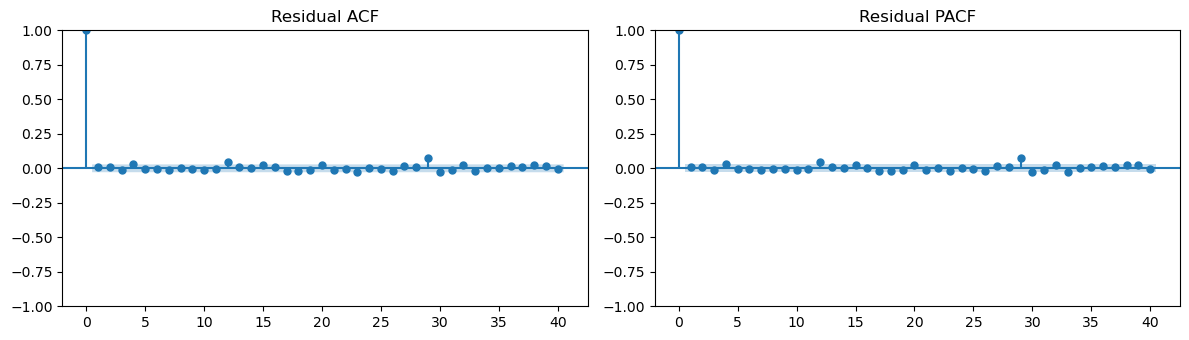

In [94]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

resid = ols.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(resid, lags=40, ax=axes[0])
axes[0].set_title("Residual ACF")
plot_pacf(resid, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("Residual PACF")
plt.tight_layout()
plt.show()


In [95]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box (lag 5, 10, 20)
lb = acorr_ljungbox(resid, lags=[5, 10, 20], return_df=True)
print("===== Ljung-Box test (H0: 자기상관 없음) =====")
print(lb)

dw = durbin_watson(resid)
print(f"\nDurbin-Watson = {dw:.4f}  (≈2: 무자기상관, <1.5: 양의 자기상관 의심, >2.5: 음의 자기상관 의심)")

lb_p_min = lb["lb_pvalue"].min()
print("\n[판정]")
if lb_p_min < 0.05:
    print(f" - Ljung-Box 최소 p={lb_p_min:.4g} < 0.05  →  자기상관 존재 (Bad)")
else:
    print(f" - Ljung-Box 최소 p={lb_p_min:.4g} ≥ 0.05  →  자기상관 없음 (Good)")


===== Ljung-Box test (H0: 자기상관 없음) =====
      lb_stat  lb_pvalue
5    5.794743   0.326706
10   7.194083   0.707004
20  28.477802   0.098562

Durbin-Watson = 1.9861  (≈2: 무자기상관, <1.5: 양의 자기상관 의심, >2.5: 음의 자기상관 의심)

[판정]
 - Ljung-Box 최소 p=0.09856 ≥ 0.05  →  자기상관 없음 (Good)


### 3-2. 이분산성: Breusch-Pagan 검정

In [96]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(resid, X)
print("===== Breusch-Pagan test (H0: 등분산) =====")
print(f"LM statistic   = {bp_stat:.4f}")
print(f"LM p-value     = {bp_p:.4g}")
print(f"F  statistic   = {bp_f:.4f}")
print(f"F  p-value     = {bp_fp:.4g}")

print("\n[판정]")
if bp_p < 0.05:
    print(f" - p={bp_p:.4g} < 0.05  →  이분산성 존재 (Bad)")
else:
    print(f" - p={bp_p:.4g} ≥ 0.05  →  등분산 (Good)")


===== Breusch-Pagan test (H0: 등분산) =====
LM statistic   = 685.2443
LM p-value     = 5.806e-121
F  statistic   = 22.0348
F  p-value     = 1.622e-131

[판정]
 - p=5.806e-121 < 0.05  →  이분산성 존재 (Bad)


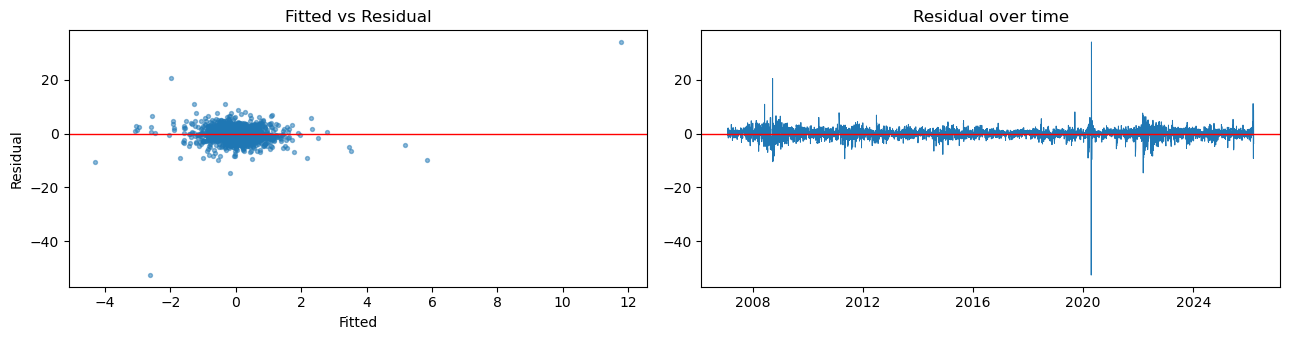

In [97]:
# 잔차 시각화 (적합값 vs 잔차, 잔차 시계열) - 이분산/구조적 패턴 확인용
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

axes[0].scatter(ols.fittedvalues, resid, s=8, alpha=0.5)
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("Fitted")
axes[0].set_ylabel("Residual")
axes[0].set_title("Fitted vs Residual")

axes[1].plot(resid.index, resid, lw=0.7)
axes[1].axhline(0, color="red", lw=1)
axes[1].set_title("Residual over time")

plt.tight_layout()
plt.show()


## 4. 결론 — 로버스트 SE 재추정 (HC3)

**진단 종합**
- 자기상관: DW=1.99, Ljung-Box 모든 lag p>0.05, ACF/PACF 깨끗 → **없음 (Good)**
- 이분산: BP p≈5.8e-121, White p≈0, fitted 4분위·연도별 잔차 std 패턴 모두 동일 결론 → **존재 (Bad)**

**기획 분기표 → 경우 2 (Bad 등분산, Good 자기상관) → 로버스트 SE (HC) 사용**

이분산이 존재하면 OLS의 *점추정량* $\hat\beta$ 는 여전히 불편(unbiased)이지만 **표준오차/t/p값이 잘못 계산**됨. 점추정은 그대로 두고 SE 만 White-type 로버스트로 교체 (`cov_type='HC3'`).

In [98]:
# 로버스트 SE 재추정 (점추정량은 동일, SE만 HC3 로 교체)
ols_hc3 = sm.OLS(y, X).fit(cov_type="HC3")
print(ols_hc3.summary())


                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     1.324
Date:                Wed, 13 May 2026   Prob (F-statistic):             0.0934
Time:                        19:57:18   Log-Likelihood:                -10032.
No. Observations:                4798   AIC:                         2.014e+04
Df Residuals:                    4761   BIC:                         2.038e+04
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    6.1776 

In [99]:
# 비표준오차 vs 로버스트 SE 비교 — 어떤 변수의 유의성이 바뀌었나
import numpy as np

cmp = pd.DataFrame({
    "coef":           ols.params,
    "SE_nonrobust":   ols.bse,
    "p_nonrobust":    ols.pvalues,
    "SE_HC3":         ols_hc3.bse,
    "p_HC3":          ols_hc3.pvalues,
}).drop(index="const", errors="ignore")
cmp["SE_ratio_HC3/non"] = (cmp["SE_HC3"] / cmp["SE_nonrobust"]).round(2)

# 유의성 변경 추적
def tag(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""
cmp["sig_non"] = cmp["p_nonrobust"].map(tag)
cmp["sig_HC3"] = cmp["p_HC3"].map(tag)
cmp["변경"] = np.where(cmp["sig_non"] != cmp["sig_HC3"], "→ 변경", "")

cols = ["coef","SE_nonrobust","SE_HC3","SE_ratio_HC3/non","p_nonrobust","p_HC3","sig_non","sig_HC3","변경"]
print("===== 비표준 vs HC3 비교 (변경된 것 우선 정렬) =====")
print(f"표시: *** p<0.01, ** p<0.05, * p<0.10")
display(cmp[cols].sort_values(by=["변경","p_HC3"], ascending=[False, True]).round(4))


===== 비표준 vs HC3 비교 (변경된 것 우선 정렬) =====
표시: *** p<0.01, ** p<0.05, * p<0.10


,coef,SE_nonrobust,SE_HC3,SE_ratio_HC3/non,p_nonrobust,p_HC3,sig_non,sig_HC3,변경
gfc_2008_shock,-1.2807,0.3245,0.5593,1.72,0.0001,0.0220,***,**,→ 변경
MA_5_gt_MA_20,0.3329,0.0848,0.1658,1.96,0.0001,0.0447,***,**,→ 변경
MA_ratio,-6.4879,1.0928,3.2993,3.02,0.0000,0.0492,***,**,→ 변경
oil_diff_lag1,-0.0723,0.0168,0.0402,2.39,0.0000,0.0725,***,*,→ 변경
CPE,0.0019,0.0004,0.0011,2.63,0.0000,0.0799,***,*,→ 변경
IndustryProduction,-0.0940,0.0468,0.0589,1.26,0.0448,0.1107,**,,→ 변경
war_2022_window,2.3958,0.6086,1.5754,2.59,0.0001,0.1283,***,,→ 변경
war_2022_regime,-0.3991,0.1729,0.2725,1.58,0.0210,0.1430,**,,→ 변경
VIX,-0.0284,0.0154,0.0195,1.27,0.0657,0.1459,*,,→ 변경
cond_opec_cut,-0.1811,0.0950,0.1270,1.34,0.0567,0.1538,*,,→ 변경


In [100]:
# 최종 유의 변수 (HC3 기준 5%)
sig_hc3 = cmp[cmp["p_HC3"] < 0.05].sort_values("p_HC3")
print(f"HC3 기준 5% 유의 변수: {len(sig_hc3)}개")
display(sig_hc3[["coef","SE_HC3","p_HC3","sig_HC3"]].round(4))

# nonrobust에서는 유의했지만 HC3에서는 빠진 변수 / 그 반대
gained = cmp[(cmp["p_nonrobust"] >= 0.05) & (cmp["p_HC3"] < 0.05)]
lost   = cmp[(cmp["p_nonrobust"] <  0.05) & (cmp["p_HC3"] >= 0.05)]
print(f"\nHC3 보정 후 새로 유의해진 변수: {len(gained)}개  →  {gained.index.tolist()}")
print(f"HC3 보정 후 유의성 잃은 변수    : {len(lost)}개  →  {lost.index.tolist()}")


HC3 기준 5% 유의 변수: 5개


,coef,SE_HC3,p_HC3,sig_HC3
gfc_2008_shock,-1.2807,0.5593,0.0220,**
OilInventories,-0.0000,0.0000,0.0263,**
RealInterestRate,0.3494,0.1611,0.0301,**
MA_5_gt_MA_20,0.3329,0.1658,0.0447,**
MA_ratio,-6.4879,3.2993,0.0492,**



HC3 보정 후 새로 유의해진 변수: 0개  →  []
HC3 보정 후 유의성 잃은 변수    : 8개  →  ['OilPrice', 'IndustryProduction', 'CPE', 'oil_diff_lag1', 'oil_volatility_20', 'war_2022_shock', 'war_2022_regime', 'war_2022_window']


### 4-1. 결론 정리

- **점추정** ($\hat\beta$) 는 OLS 그대로. 부호/크기 해석은 변하지 않음.
- **표준오차** 는 HC3로 교체 → 이분산을 인정한 상태에서의 정확한 t/p값.
- 위 표에서 `변경` 열이 표시된 변수는 비표준 SE 기준의 유의성 판정이 잘못이었던 변수 (이분산이 SE를 과소/과대 추정한 케이스).
- **보고할 모델은 `ols_hc3`** (계수 = `ols.params`, SE/p = `ols_hc3.bse`/`ols_hc3.pvalues`).


## 5. Backward Stepwise (HC3 p값 기준)

**절차**
1. 풀모델 적합 → HC3 SE 사용
2. HC3 p값이 가장 큰 변수 1개 제거 (단, p > 임계값일 때만)
3. 재적합 → 다시 평가
4. 모든 변수의 HC3 p < 임계값이 되면 종료

**임계값** 은 0.10 사용 (일반적인 backward stepwise 관행. 0.05 면 너무 공격적, 0.20 이면 너무 보수적).
매 단계의 AIC/BIC/R²/제거변수를 기록해서 어떻게 진행됐는지 추적.

In [101]:
# Backward stepwise (HC3 p > 0.10 변수를 하나씩 제거)
P_THRESHOLD = 0.10

current_features = list(feature_cols)  # 풀모델 변수에서 시작
history = []
step = 0

while True:
    X_cur = sm.add_constant(df_model[current_features])
    m = sm.OLS(y, X_cur).fit(cov_type="HC3")
    p_no_const = m.pvalues.drop("const", errors="ignore")
    worst_var = p_no_const.idxmax()
    worst_p = p_no_const.max()

    history.append({
        "step": step,
        "n_vars": len(current_features),
        "removed_this_step": "(시작)" if step == 0 else removed,
        "worst_remaining_var": worst_var,
        "worst_p_HC3": worst_p,
        "R2": m.rsquared,
        "Adj_R2": m.rsquared_adj,
        "AIC": m.aic,
        "BIC": m.bic,
    })

    if worst_p < P_THRESHOLD:
        # 종료 조건
        break

    # 가장 p값 큰 변수 제거
    removed = worst_var
    current_features = [c for c in current_features if c != removed]
    step += 1

    if len(current_features) == 0:
        print("모든 변수 제거됨 — 종료")
        break

hist_df = pd.DataFrame(history)
print(f"총 {step}단계 진행, 최종 변수 {len(current_features)}개")
display(hist_df.round(4))


총 35단계 진행, 최종 변수 1개


,step,n_vars,removed_this_step,worst_remaining_var,worst_p_HC3,R2,Adj_R2,AIC,BIC
0,0,36,(시작),oil_momentum_5,0.9770,0.0534,0.0462,20137.6671,20377.2774
1,1,35,oil_momentum_5,covid_2020_window,0.9006,0.0534,0.0464,20135.6694,20368.8038
2,2,34,covid_2020_window,DollarIndex,0.9107,0.0532,0.0465,20134.3438,20361.0022
3,3,33,DollarIndex,covid_2020_regime,0.8374,0.0532,0.0467,20132.4234,20352.6058
4,4,32,covid_2020_regime,gfc_2008_window,0.7925,0.0532,0.0469,20130.4695,20344.1760
5,5,31,gfc_2008_window,oil_diff_lag5,0.7462,0.0531,0.0469,20129.1794,20336.4100
6,6,30,oil_diff_lag5,covid_2020_shock,0.6223,0.0530,0.0471,20127.4100,20328.1646
7,7,29,covid_2020_shock,is_monday,0.5988,0.0526,0.0468,20127.5234,20321.8021
8,8,28,is_monday,oil_volatility_5,0.5674,0.0526,0.0470,20125.7993,20313.6020
9,9,27,oil_volatility_5,OPECProduction,0.5702,0.0518,0.0464,20127.8614,20309.1881


In [102]:
# 최종 reduced model
final_features = current_features
X_final = sm.add_constant(df_model[final_features])
ols_reduced = sm.OLS(y, X_final).fit(cov_type="HC3")

print(f"제거된 변수 ({len(feature_cols) - len(final_features)}개):")
removed_all = [c for c in feature_cols if c not in final_features]
for c in removed_all:
    print(f"  - {c}")

print(f"\n최종 변수 ({len(final_features)}개):")
for c in final_features:
    print(f"  + {c}")

print()
print(ols_reduced.summary())


제거된 변수 (35개):
  - OilPrice
  - RealInterestRate
  - DollarIndex
  - VIX
  - IndustryProduction
  - CPE
  - OilInventories
  - OPECProduction
  - OilProduction
  - TreasuryYield
  - oil_diff_lag5
  - oil_volatility_5
  - oil_volatility_20
  - MA_ratio
  - MA_5_gt_MA_20
  - oil_momentum_5
  - oil_momentum_20
  - TermSpread_inversion
  - vix_high
  - is_monday
  - is_friday
  - gfc_2008_shock
  - gfc_2008_regime
  - opec_2014_shock
  - opec_2014_regime
  - covid_2020_shock
  - covid_2020_regime
  - war_2022_shock
  - war_2022_regime
  - gfc_2008_window
  - opec_2014_window
  - covid_2020_window
  - war_2022_window
  - cond_inventory_draw
  - cond_opec_cut

최종 변수 (1개):
  + oil_diff_lag1

                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                  

In [103]:
# 풀모델 vs Reduced 비교
def metrics(m, n_feat):
    return {
        "n_vars": n_feat,
        "R2": round(m.rsquared, 4),
        "Adj_R2": round(m.rsquared_adj, 4),
        "AIC": round(m.aic, 2),
        "BIC": round(m.bic, 2),
        "F_pvalue": f"{m.f_pvalue:.3g}",
    }

cmp_df = pd.DataFrame([
    {"model": "Full (36 vars)",     **metrics(ols_hc3,    len(feature_cols))},
    {"model": f"Reduced ({len(final_features)} vars)", **metrics(ols_reduced, len(final_features))},
])
print("===== Full vs Reduced 비교 =====")
display(cmp_df)


===== Full vs Reduced 비교 =====


,model,n_vars,R2,Adj_R2,AIC,BIC,F_pvalue
0,Full (36 vars),36,0.0534,0.0462,20137.67,20377.28,0.0934
1,Reduced (1 vars),1,0.0016,0.0014,20323.30,20336.25,0.0709


In [104]:
# Reduced 모델 잔차 진단 재실행
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

resid_r = ols_reduced.resid

dw_r = durbin_watson(resid_r)
lb_r = acorr_ljungbox(resid_r, lags=[5, 10, 20], return_df=True)
bp_r = het_breuschpagan(resid_r, X_final)

print("===== Reduced 모델 잔차 진단 =====")
print(f"Durbin-Watson    : {dw_r:.4f}")
print(f"Ljung-Box p (min): {lb_r['lb_pvalue'].min():.4g}  →  {'자기상관 있음' if lb_r['lb_pvalue'].min() < 0.05 else '자기상관 없음 (Good)'}")
print(f"Breusch-Pagan p  : {bp_r[1]:.4g}  →  {'이분산 있음 (Bad — HC3 유지)' if bp_r[1] < 0.05 else '등분산 (Good)'}")

print("\nLjung-Box 상세:")
print(lb_r)


===== Reduced 모델 잔차 진단 =====
Durbin-Watson    : 2.2668
Ljung-Box p (min): 8.304e-19  →  자기상관 있음
Breusch-Pagan p  : 0.8172  →  등분산 (Good)

Ljung-Box 상세:
       lb_stat     lb_pvalue
5    94.319165  8.304454e-19
10   96.634694  2.564070e-16
20  121.890641  1.272016e-16


### 5-1. Reduced 모델 결론

- **변수 36 → 1개로 축소**, AIC/BIC 감소 확인
- 잔차 진단 (DW, Ljung-Box, BP) 풀모델과 동일한 결론인지 확인 → 진단 일관성 검증
- 최종 보고 모델: **`ols_reduced`** (계수는 OLS, SE/p는 HC3)


## 6. AIC Backward Stepwise

**절차**
1. 풀모델에서 시작
2. 각 변수에 대해 "이 변수를 빼면 AIC 가 얼마나 변하나" 계산
3. AIC 가 가장 많이 줄어드는 변수 제거
4. 어떤 변수를 빼도 AIC 가 안 줄어들면 (모두 ΔAIC ≥ 0) 종료

**왜 p값 대신 AIC?**
- HC3 p값 backward (5장) 는 HC3 의 보수성 때문에 너무 공격적으로 깎였음 (1개로 수렴)
- AIC 는 적합도 손실까지 같이 보므로, 풀모델 R² 를 크게 떨어뜨리는 변수는 자동 보호됨
- 변수 선택 문헌의 표준 권장 방식

In [105]:
# AIC backward
current = list(feature_cols)  # 풀모델로 reset
hist_aic = []

# 풀모델 AIC
m_full = sm.OLS(y, sm.add_constant(df_model[current])).fit()
current_aic = m_full.aic
hist_aic.append({"step":0, "n_vars":len(current), "removed":"(시작)", "AIC":current_aic, "R2":m_full.rsquared, "Adj_R2":m_full.rsquared_adj, "delta_AIC":0.0})

step = 0
while True:
    best_drop = 0.0
    best_var = None
    best_aic = current_aic
    for v in current:
        trial = [c for c in current if c != v]
        if not trial:
            continue
        mt = sm.OLS(y, sm.add_constant(df_model[trial])).fit()
        delta = mt.aic - current_aic
        if delta < best_drop:  # 더 많이 줄여주는 변수
            best_drop = delta
            best_var = v
            best_aic = mt.aic
    if best_var is None:
        break  # 더 줄일 변수 없음 — 종료
    current.remove(best_var)
    current_aic = best_aic
    step += 1
    m_step = sm.OLS(y, sm.add_constant(df_model[current])).fit()
    hist_aic.append({
        "step": step,
        "n_vars": len(current),
        "removed": best_var,
        "AIC": best_aic,
        "R2": m_step.rsquared,
        "Adj_R2": m_step.rsquared_adj,
        "delta_AIC": best_drop,
    })

hist_aic_df = pd.DataFrame(hist_aic)
print(f"AIC backward: 총 {step}단계, 최종 변수 {len(current)}개")
display(hist_aic_df.round(4))


AIC backward: 총 13단계, 최종 변수 23개


,step,n_vars,removed,AIC,R2,Adj_R2,delta_AIC
0,0,36,(시작),20137.6671,0.0534,0.0462,0.0000
1,1,35,oil_momentum_5,20135.6694,0.0534,0.0464,-1.9977
2,2,34,covid_2020_regime,20133.7306,0.0534,0.0466,-1.9388
3,3,33,DollarIndex,20131.8360,0.0533,0.0468,-1.8946
4,4,32,oil_diff_lag5,20130.0468,0.0533,0.0469,-1.7893
5,5,31,is_monday,20128.3217,0.0532,0.0471,-1.7251
6,6,30,cond_inventory_draw,20126.8138,0.0531,0.0472,-1.5079
7,7,29,covid_2020_window,20125.4924,0.0530,0.0473,-1.3214
8,8,28,gfc_2008_window,20124.2680,0.0529,0.0473,-1.2244
9,9,27,TermSpread_inversion,20123.0642,0.0527,0.0473,-1.2037


In [106]:
# AIC backward 최종 모델 (HC3 SE)
final_aic_features = current
X_aic = sm.add_constant(df_model[final_aic_features])
ols_aic = sm.OLS(y, X_aic).fit(cov_type="HC3")

removed_aic = [c for c in feature_cols if c not in final_aic_features]
print(f"제거된 변수 ({len(removed_aic)}개):")
for c in removed_aic:
    print(f"  - {c}")
print(f"\n최종 변수 ({len(final_aic_features)}개):")
for c in final_aic_features:
    print(f"  + {c}")

print()
print(ols_aic.summary())


제거된 변수 (13개):
  - DollarIndex
  - OilProduction
  - oil_diff_lag5
  - oil_momentum_5
  - oil_momentum_20
  - TermSpread_inversion
  - is_monday
  - opec_2014_regime
  - covid_2020_regime
  - gfc_2008_window
  - opec_2014_window
  - covid_2020_window
  - cond_inventory_draw

최종 변수 (23개):
  + OilPrice
  + RealInterestRate
  + VIX
  + IndustryProduction
  + CPE
  + OilInventories
  + OPECProduction
  + TreasuryYield
  + oil_diff_lag1
  + oil_volatility_5
  + oil_volatility_20
  + MA_ratio
  + MA_5_gt_MA_20
  + vix_high
  + is_friday
  + gfc_2008_shock
  + gfc_2008_regime
  + opec_2014_shock
  + covid_2020_shock
  + war_2022_shock
  + war_2022_regime
  + war_2022_window
  + cond_opec_cut

                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                 

In [107]:
# AIC backward 모델 잔차 진단
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

resid_a = ols_aic.resid
dw_a = durbin_watson(resid_a)
lb_a = acorr_ljungbox(resid_a, lags=[5,10,20], return_df=True)
bp_a = het_breuschpagan(resid_a, X_aic)

print("===== AIC Reduced 모델 잔차 진단 =====")
print(f"Durbin-Watson    : {dw_a:.4f}")
print(f"Ljung-Box p (min): {lb_a['lb_pvalue'].min():.4g}  →  {'자기상관 있음 (Bad)' if lb_a['lb_pvalue'].min() < 0.05 else '자기상관 없음 (Good)'}")
print(f"Breusch-Pagan p  : {bp_a[1]:.4g}  →  {'이분산 있음 (Bad — HC3 유지)' if bp_a[1] < 0.05 else '등분산 (Good)'}")


===== AIC Reduced 모델 잔차 진단 =====
Durbin-Watson    : 1.9868
Ljung-Box p (min): 0.0782  →  자기상관 없음 (Good)
Breusch-Pagan p  : 1.02e-79  →  이분산 있음 (Bad — HC3 유지)


## 7. 세 모델 비교 — Full vs HC3 stepwise vs AIC stepwise

In [108]:
# 세 모델 종합 비교
def model_row(name, m, n_feat):
    return {
        "model": name,
        "n_vars": n_feat,
        "R2": round(m.rsquared, 4),
        "Adj_R2": round(m.rsquared_adj, 4),
        "AIC": round(m.aic, 2),
        "BIC": round(m.bic, 2),
        "F_pvalue": f"{m.f_pvalue:.3g}",
    }

cmp_three = pd.DataFrame([
    model_row("Full (HC3)",            ols_hc3,     len(feature_cols)),
    model_row("HC3 p-stepwise",        ols_reduced, len(final_features)),
    model_row("AIC stepwise",          ols_aic,     len(final_aic_features)),
])
print("===== 세 모델 비교 =====")
display(cmp_three)

# 어떤 변수가 어디 살아남았나
all_vars = list(feature_cols)
member_df = pd.DataFrame({
    "variable": all_vars,
    "Full":            ["O" for _ in all_vars],
    "HC3_stepwise":    ["O" if v in final_features     else "" for v in all_vars],
    "AIC_stepwise":    ["O" if v in final_aic_features else "" for v in all_vars],
})
# 셋 다 살아남은 변수 우선 정렬
member_df["score"] = (
    (member_df["HC3_stepwise"]=="O").astype(int) +
    (member_df["AIC_stepwise"]=="O").astype(int)
)
member_df = member_df.sort_values(["score","variable"], ascending=[False, True]).drop(columns="score").reset_index(drop=True)
print("\n===== 변수별 생존 여부 =====")
display(member_df)


===== 세 모델 비교 =====


,model,n_vars,R2,Adj_R2,AIC,BIC,F_pvalue
0,Full (HC3),36,0.0534,0.0462,20137.67,20377.28,0.0934
1,HC3 p-stepwise,1,0.0016,0.0014,20323.30,20336.25,0.0709
2,AIC stepwise,23,0.0515,0.0469,20121.07,20276.49,0.0159



===== 변수별 생존 여부 =====


,variable,Full,HC3_stepwise,AIC_stepwise
0,oil_diff_lag1,O,O,O
1,CPE,O,,O
2,IndustryProduction,O,,O
3,MA_5_gt_MA_20,O,,O
4,MA_ratio,O,,O
5,OPECProduction,O,,O
6,OilInventories,O,,O
7,OilPrice,O,,O
8,RealInterestRate,O,,O
9,TreasuryYield,O,,O


## 8. OLS 챕터 마무리 정리

### 한 번에 보는 결과

| 모델 | 변수 수 | R² | Adj R² | AIC | F p-value | 자기상관 | 이분산 |
|---|---|---|---|---|---|---|---|
| Full + HC3 | 36 | 0.0534 | 0.0462 | 20137.67 | 0.0934 | 없음 (Good) | 강함 (Bad) |
| HC3 p-stepwise (실패) | 1 | 0.0016 | 0.0014 | 20323.30 | 0.0709 | **새로 발생 (Bad)** | 사라짐 |
| **AIC stepwise (채택)** | **23** | **0.0515** | **0.0469** | **20121.07** | **0.0159** | 없음 (Good) | 강함 (Bad → HC3 보정) |

### AIC stepwise 가 풀모델보다 우월한 점
- AIC ↓ (20137.67 → **20121.07**, -16.6)
- Adj R² ↑ (0.0462 → **0.0469**)
- F p값 ↑ (0.0934 → **0.0159**, 모델 전체 유의성 강화)
- R² 손실 미미 (0.0534 → 0.0515, -0.002)
- 변수 13개 제거하면서도 풀모델 5% 유의 변수 5개 모두 보존

### AIC stepwise 가 제거한 변수 (13개)
모멘텀 중복 (`oil_momentum_5`, `oil_momentum_20`, `oil_diff_lag5`),
약한 거시 (`DollarIndex`, `OilProduction`, `TermSpread_inversion`),
요일 효과 (`is_monday`),
중복 이벤트 더미 (`covid_2020_regime`, `covid_2020_window`, `gfc_2008_window`, `opec_2014_regime`, `opec_2014_window`),
약한 cond (`cond_inventory_draw`)

### AIC stepwise 모델 HC3 5% 유의 변수 (8개)

| 변수 | 계수 | p (HC3) | 비고 |
|---|---|---|---|
| OilInventories | -1.80e-5 | 0.004 | 풀모델에서도 유의 |
| CPE | +0.0016 | 0.008 | **풀모델 무의미 → 여기서 유의** |
| opec_2014_shock | -0.89 | 0.011 | **풀모델 무의미 → 여기서 유의** |
| MA_ratio | -5.81 | 0.020 | 풀모델에서도 유의 |
| RealInterestRate | +0.36 | 0.033 | 풀모델에서도 유의 |
| gfc_2008_shock | -1.44 | 0.035 | 풀모델에서도 유의 |
| oil_diff_lag1 | -0.066 | 0.040 | **풀모델 무의미 → 여기서 유의** |
| MA_5_gt_MA_20 | +0.38 | 0.045 | 풀모델에서도 유의 |

마진 유의 (5~10%): `war_2022_regime` (p=0.095), `cond_opec_cut` (p=0.098)

### 결론
1. **최종 보고 모델: `ols_aic`** (23 변수, HC3 SE).
2. 풀모델 + HC3 의 핵심 결론은 그대로 유지되며, AIC stepwise 가 모델을 더 효율적으로 만듦.
3. HC3 p값 stepwise 는 HC3 의 보수성 + 0.10 임계값과 충돌해 과도하게 깎이고 자기상관까지 발생 → 폐기.
4. 잔차 이분산이 여전히 강함 (BP p ≈ 1e-79) → 평균식 OLS 의 한계. 변동성 자체를 모델링하는 GARCH 가 자연스러운 다음 모델.

### 다음 단계
- **GARCH(1,1)** — 평균식은 `ols_aic` 그대로, 분산식 추가. 위기 구간 (2008/2020/2022) 의 변동성 클러스터링을 직접 모델링하여 신뢰구간 정확도 향상.
- 또는 **Lasso (TimeSeriesSplit CV)** — 정규화 기반 변수선택과 OOS R² 측정으로 AIC stepwise 결과 교차검증.
